# A2A — KG + Activation Steering vs Activation Only

Focused evaluation comparing the two pipeline branches across 100 cases.

| Branch | JSONL key | Description |
|--------|-----------|-------------|
| **KG + Steering (Mode A)** | `rec["kg_steering"]` | Builds Knowledge Graph → steers activations with KG context |
| **Activation Only (Mode B)** | `rec["activation_only"]` | Pure activation steering, no KG |

All charts show: **Blue = KG+Steering · Orange = Activation Only · Δ = A − B**

In [1]:
# Cell 1 — Install Dependencies
import subprocess, sys

pkgs = ["rouge_score", "textstat", "nltk", "scipy",
        "matplotlib", "seaborn", "pandas", "numpy"]
for pkg in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import nltk
nltk.download("punkt",      quiet=True)
nltk.download("punkt_tab",  quiet=True)

print("✓ Dependencies ready.")


✓ Dependencies ready.


## Cell 2 — Load Results & Extract Metrics

Reads the latest `outputs/results_*.jsonl`. Extracts `a_*` (KG+Steering) and `b_*` (Activation Only) metrics for every case.

In [2]:
# Cell 2 — Load & Extract Metrics
import json, re, warnings
from pathlib import Path
from collections import defaultdict
from typing import Optional

import numpy as np
import pandas as pd
from scipy import stats
from rouge_score import rouge_scorer
import textstat
from nltk.tokenize import word_tokenize, sent_tokenize

warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────────
OUT_DIR = Path("outputs")  # ← folder containing results_*.jsonl

# ── Lexicons ──────────────────────────────────────────────────────────────────
EMPATHY_LEXICON = {
    "sorry","apologise","apologize","apology","understand","frustrat",
    "disappoint","upset","concern","worry","hear you","feel","difficult",
    "hard","imagine","sincerely","genuinely","truly","deeply","awful",
    "terrible","devastating","mortif","empathise","empathize","care",
    "absolutely","completely","totally","patience","reassure",
}
FORMALITY_LEXICON = {
    "acknowledge","receipt","pursuant","hereby","aforementioned",
    "notwithstanding","henceforth","kindly","advise","inform",
    "with regard","in accordance","as per","please be advised",
    "correspondence","escalat","initiat","dispatch","formal",
    "reference","case number","sla","resolution","protocol",
    "department","investigation","audit","notif","confirm",
}
PLACEHOLDER_RE = re.compile(r"<[A-Z_]{3,}>")
PASSIVE_RE      = re.compile(r"\b(is|are|was|were|be|been|being)\s+\w+ed\b", re.IGNORECASE)

# ── Helpers ───────────────────────────────────────────────────────────────────
def _tokens(t):  return word_tokenize(t.lower())
def _sents(t):   return sent_tokenize(t)
def _ttr(t):
    tk = _tokens(t); return len(set(tk))/len(tk) if tk else 0.0
def _lex(text, lex):
    tl = text.lower(); return sum(1 for w in lex if w in tl) / len(lex)
def _fp1(t):
    tk = _tokens(t)
    i = sum(1 for x in tk if x == "i"); w = sum(1 for x in tk if x == "we")
    return i/(i+w) if (i+w) else 0.0
def _passive(t):
    s = _sents(t)
    return sum(1 for x in s if PASSIVE_RE.search(x)) / len(s) if s else 0.0
def _ph(t):  return len(PLACEHOLDER_RE.findall(t))
def _rouge(hyp, ref):
    sc = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=True)
    r  = sc.score(ref, hyp)
    return {k: r[k].fmeasure for k in ("rouge1","rouge2","rougeL")}
def _ent_cov(resp, kg):
    if not kg: return {"overall": 0.0, "by_type": {}}
    nodes = kg.get("nodes", [])
    if not nodes: return {"overall": 0.0, "by_type": {}}
    bt = defaultdict(list); total = 0
    for n in nodes:
        v, t = n.get("value","").lower(), n.get("type","UNK")
        f = int(v in resp.lower()) if v else 0
        bt[t].append(f); total += f
    return {"overall": total/len(nodes),
            "by_type": {t: sum(v)/len(v) for t,v in bt.items()}}
def _kgd(kg):
    if not kg: return 0.0
    n, e = len(kg.get("nodes",[])), len(kg.get("edges",[]))
    return e/(n*(n-1)) if n > 1 else 0.0

def _response_metrics(text, kg, prefix):
    """Compute all per-response metrics; return NaN dict if text is empty."""
    NAN = float("nan")
    if not text or not text.strip():
        return {f"{prefix}_{k}": NAN for k in [
            "token_len","sent_len","ttr","flesch_ease","flesch_grade","fog",
            "empathy_score","formality_score","fp_singular","passive",
            "placeholder","entity_cov"]}
    ec = _ent_cov(text, kg)
    d  = {
        f"{prefix}_token_len":       len(_tokens(text)),
        f"{prefix}_sent_len":        len(_sents(text)),
        f"{prefix}_ttr":             _ttr(text),
        f"{prefix}_flesch_ease":     textstat.flesch_reading_ease(text),
        f"{prefix}_flesch_grade":    textstat.flesch_kincaid_grade(text),
        f"{prefix}_fog":             textstat.gunning_fog(text),
        f"{prefix}_empathy_score":   _lex(text, EMPATHY_LEXICON),
        f"{prefix}_formality_score": _lex(text, FORMALITY_LEXICON),
        f"{prefix}_fp_singular":     _fp1(text),
        f"{prefix}_passive":         _passive(text),
        f"{prefix}_placeholder":     _ph(text),
        f"{prefix}_entity_cov":      ec["overall"],
    }
    for t, v in ec["by_type"].items():
        d[f"{prefix}_cov_{t.lower()}"] = v
    return d

def extract_metrics(rec: dict) -> Optional[dict]:
    """Extract a_* / b_* / delta_* metrics from a single JSONL record."""
    if rec.get("status") != "success":
        return None
    if "kg_steering" not in rec or "activation_only" not in rec:
        return None

    kgs = rec["kg_steering"]
    ao  = rec["activation_only"]
    inp = rec.get("input", {})
    kg  = kgs.get("knowledge_graph", {}) or {}

    a_emp = ((kgs.get("empathetic_output") or {}).get("support_response") or "").strip()
    a_frm = ((kgs.get("formal_output")     or {}).get("support_response") or "").strip()
    b_emp = ((ao.get("empathetic_output")  or {}).get("support_response") or "").strip()
    b_frm = ((ao.get("formal_output")      or {}).get("support_response") or "").strip()

    if not a_emp:   # KG+Steering empathetic response is required
        return None

    cm = inp.get("customer_message", "")
    row = {
        "case_index": rec.get("case_index"),
        "scenario":   inp.get("scenario"),
        "sentiment":  inp.get("sentiment"),
        "urgency":    inp.get("urgency"),
    }

    # ── Mode A (KG+Steering) and Mode B (Activation Only) response metrics ────
    row.update(_response_metrics(a_emp, kg,   "a_emp"))
    row.update(_response_metrics(a_frm, kg,   "a_frm"))
    row.update(_response_metrics(b_emp, None, "b_emp"))  # no KG for Mode B
    row.update(_response_metrics(b_frm, None, "b_frm"))

    # ── ROUGE (cross-style divergence within each mode) ───────────────────────
    if a_emp and a_frm:
        r = _rouge(a_emp, a_frm)
        row.update({"a_rouge1_ef": r["rouge1"], "a_rouge2_ef": r["rouge2"],
                    "a_rougeL_ef": r["rougeL"]})
        row["a_rouge1_ec"] = _rouge(a_emp, cm)["rouge1"] if cm else float("nan")
    else:
        row.update({k: float("nan") for k in
                    ["a_rouge1_ef","a_rouge2_ef","a_rougeL_ef","a_rouge1_ec"]})

    if b_emp and b_frm:
        r = _rouge(b_emp, b_frm)
        row.update({"b_rouge1_ef": r["rouge1"], "b_rouge2_ef": r["rouge2"],
                    "b_rougeL_ef": r["rougeL"]})
        row["b_rouge1_ec"] = _rouge(b_emp, cm)["rouge1"] if cm else float("nan")
    else:
        row.update({k: float("nan") for k in
                    ["b_rouge1_ef","b_rouge2_ef","b_rougeL_ef","b_rouge1_ec"]})

    # ── Style discrimination (empathy-formality gap) ──────────────────────────
    ae = row["a_emp_empathy_score"]; af = row["a_emp_formality_score"]
    fe = row["a_frm_empathy_score"]; ff = row["a_frm_formality_score"]
    row["a_style_disc_score"] = (ae-fe) - (af-ff) if all(v==v for v in [ae,af,fe,ff]) else float("nan")

    be = row["b_emp_empathy_score"]; bf = row["b_emp_formality_score"]
    ge = row["b_frm_empathy_score"]; gf = row["b_frm_formality_score"]
    row["b_style_disc_score"] = (be-ge) - (bf-gf) if all(v==v for v in [be,bf,ge,gf]) else float("nan")

    # ── Delta = Mode A − Mode B (positive = KG+Steering wins) ────────────────
    DELTA_KEYS = [
        "emp_empathy_score", "frm_formality_score", "style_disc_score",
        "emp_token_len",     "emp_ttr",             "emp_flesch_ease",
        "emp_fog",           "emp_placeholder",      "emp_entity_cov",
        "rouge1_ef",         "rouge2_ef",
    ]
    for mk in DELTA_KEYS:
        av = row.get(f"a_{mk}", float("nan"))
        bv = row.get(f"b_{mk}", float("nan"))
        row[f"delta_{mk}"] = (av - bv) if (av==av and bv==bv) else float("nan")

    # ── KG structural metrics ─────────────────────────────────────────────────
    nodes = kg.get("nodes", [])
    edges = kg.get("edges", [])
    row["kg_nodes"]    = len(nodes)
    row["kg_edges"]    = len(edges)
    row["kg_density"]  = _kgd(kg)
    row["kg_salience"] = float(np.mean([n.get("salience",0) for n in nodes])) if nodes else 0.0

    return row

# ── Load ──────────────────────────────────────────────────────────────────────
jsonl_files = sorted(OUT_DIR.glob("results_*.jsonl"))
if not jsonl_files:
    raise FileNotFoundError(f"No results_*.jsonl found in {OUT_DIR}")

latest = jsonl_files[-1]
print(f"Reading: {latest}")

raw = []
with open(latest, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line: continue
        try: raw.append(json.loads(line))
        except json.JSONDecodeError: pass

# ── Normalise steering_mode labels ────────────────────────────────────────────
# The activation_only branch stored "standard_activation" internally, which is
# misleading (it implies "no steering").  Rename to "activation_only_steering"
# so both branches follow the same <method>_<mode> convention:
#   kg_steering.*  →  steering_mode = "kg_activation"          (unchanged)
#   activation_only.* → steering_mode = "activation_only_steering"  (fixed)
# This rename is cosmetic only; the evaluation reads rec["kg_steering"] and
# rec["activation_only"] (top-level keys) and is completely unaffected.
_RENAME = {"standard_activation": "activation_only_steering"}
for rec in raw:
    ao = rec.get("activation_only", {})
    for branch in ("empathetic_output", "formal_output"):
        out = ao.get(branch, {})
        if isinstance(out, dict) and out.get("steering_mode") in _RENAME:
            out["steering_mode"] = _RENAME[out["steering_mode"]]

rows = [extract_metrics(r) for r in raw]
rows = [r for r in rows if r is not None]
DF   = pd.DataFrame(rows)

n_ok  = sum(1 for r in raw if r.get("status") == "success")
n_err = sum(1 for r in raw if r.get("status") == "error")
n_ab  = int(DF["b_emp_empathy_score"].notna().sum())

print(f"  Total records  : {len(raw)}")
print(f"  Success / Error: {n_ok} / {n_err}")
print(f"  Parsed rows    : {len(DF)}")
print(f"  Both branches  : {n_ab} (have a_* and b_* data)")
print(f"  a_* cols       : {sum(1 for c in DF.columns if c.startswith('a_'))}")
print(f"  b_* cols       : {sum(1 for c in DF.columns if c.startswith('b_'))}")
print(f"  delta_* cols   : {sum(1 for c in DF.columns if c.startswith('delta_'))}")

# Verify steering_mode labels after normalisation
_modes = {}
for rec in raw:
    for top_key in ("kg_steering", "activation_only"):
        branch_data = rec.get(top_key, {})
        for out_key in ("empathetic_output", "formal_output"):
            out = branch_data.get(out_key, {})
            if isinstance(out, dict) and "steering_mode" in out:
                label = f"{top_key}.{out_key}"
                _modes.setdefault(label, set()).add(out["steering_mode"])
print("\nsteering_mode values (post-normalisation):")
for label, vals in sorted(_modes.items()):
    print(f"  {label:45s} → {', '.join(sorted(vals))}")
print("\n✓ DF ready.")


Reading: outputs/results_20260526_025707.jsonl
  Total records  : 100
  Success / Error: 100 / 0
  Parsed rows    : 100
  Both branches  : 100 (have a_* and b_* data)
  a_* cols       : 41
  b_* cols       : 29
  delta_* cols   : 11

steering_mode values (post-normalisation):
  activation_only.empathetic_output             → activation_only_steering
  activation_only.formal_output                 → activation_only_steering
  kg_steering.empathetic_output                 → kg_activation
  kg_steering.formal_output                     → kg_activation

✓ DF ready.


## Cell 3 — Plot Configuration

In [3]:
# Cell 3 — Plot Configuration
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    "figure.dpi":        120,
    "font.family":       "DejaVu Sans",
    "font.size":         10,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "legend.fontsize":   9,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})
sns.set_style("whitegrid")

COLOR_A   = "#4e79a7"   # KG + Steering (blue)
COLOR_B   = "#f28e2b"   # Activation Only (orange)
COLOR_POS = "#2ca02c"   # Δ > 0  →  KG wins (green)
COLOR_NEG = "#d62728"   # Δ < 0  →  AO wins (red)

print("✓ Plot config ready.")
print(f"  Blue   {COLOR_A}  = KG + Activation Steering")
print(f"  Orange {COLOR_B}  = Activation Only (no KG)")
print(f"  Green  {COLOR_POS}  = KG+Steering wins (Δ > 0)")
print(f"  Red    {COLOR_NEG}  = Activation Only wins (Δ < 0)")


✓ Plot config ready.
  Blue   #4e79a7  = KG + Activation Steering
  Orange #f28e2b  = Activation Only (no KG)
  Green  #2ca02c  = KG+Steering wins (Δ > 0)
  Red    #d62728  = Activation Only wins (Δ < 0)


## Cell 4 — Head-to-Head: KG+Steering vs Activation Only

Side-by-side mean scores for every key metric. Δ annotation in green/red shows which branch wins.

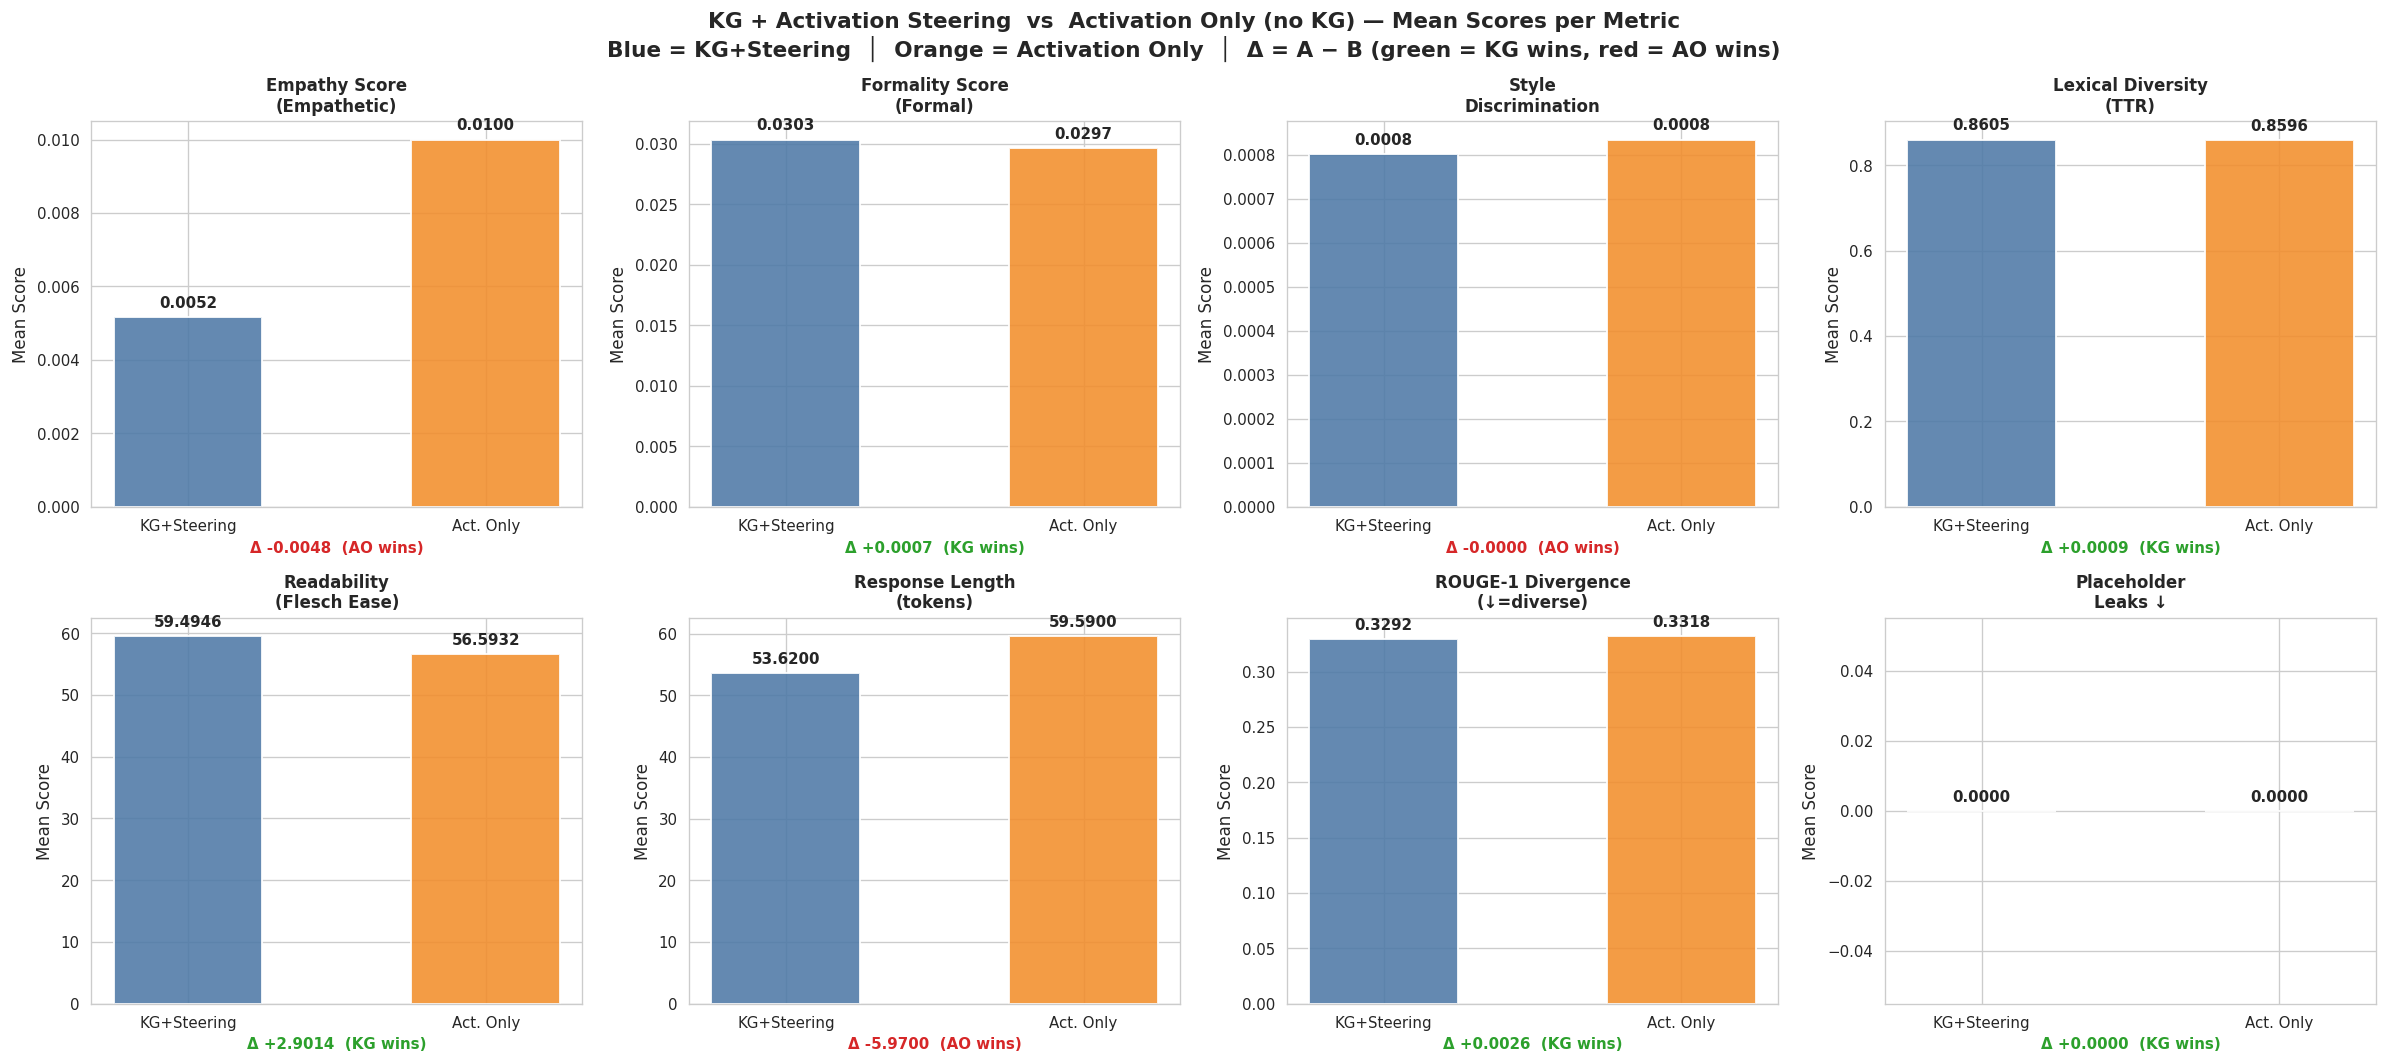

✓ Saved: eval_A_headtohead.png


In [4]:
# Cell 4 — Head-to-Head Bar Chart
COMPARE_METRICS = [
    # (Mode-A col,            Mode-B col,            label,                         higher=better)
    ("a_emp_empathy_score",   "b_emp_empathy_score",  "Empathy Score\n(Empathetic)", True),
    ("a_frm_formality_score", "b_frm_formality_score","Formality Score\n(Formal)",   True),
    ("a_style_disc_score",    "b_style_disc_score",   "Style\nDiscrimination",       True),
    ("a_emp_ttr",             "b_emp_ttr",            "Lexical Diversity\n(TTR)",    True),
    ("a_emp_flesch_ease",     "b_emp_flesch_ease",    "Readability\n(Flesch Ease)",  True),
    ("a_emp_token_len",       "b_emp_token_len",      "Response Length\n(tokens)",   True),
    ("a_rouge1_ef",           "b_rouge1_ef",          "ROUGE-1 Divergence\n(↓=diverse)", False),
    ("a_emp_placeholder",     "b_emp_placeholder",    "Placeholder\nLeaks ↓",       False),
]

n   = len(COMPARE_METRICS)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(
    "KG + Activation Steering  vs  Activation Only (no KG) — Mean Scores per Metric\n"
    "Blue = KG+Steering  │  Orange = Activation Only  │  Δ = A − B (green = KG wins, red = AO wins)",
    fontsize=13, fontweight="bold"
)

for ax, (a_col, b_col, label, higher_better) in zip(axes.flat, COMPARE_METRICS):
    av = DF[a_col].mean() if a_col in DF.columns else float("nan")
    bv = DF[b_col].mean() if b_col in DF.columns else float("nan")

    bars = ax.bar(["KG+Steering", "Act. Only"], [av, bv],
                  color=[COLOR_A, COLOR_B], alpha=0.88, width=0.5,
                  edgecolor="white", linewidth=1.2)
    ax.bar_label(bars, fmt="%.4f", fontsize=9, fontweight="bold", padding=4)

    if av == av and bv == bv:
        delta      = (av - bv) if higher_better else (bv - av)
        sign       = "+" if delta >= 0 else ""
        ann_color  = COLOR_POS if delta >= 0 else COLOR_NEG
        verdict    = "KG wins" if delta >= 0 else "AO wins"
        ax.set_xlabel(f"Δ {sign}{delta:.4f}  ({verdict})",
                      color=ann_color, fontweight="bold", fontsize=9)

    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylabel("Mean Score")
    ax.tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.savefig("eval_A_headtohead.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: eval_A_headtohead.png")


## Cell 5 — Per-Case Δ Distributions

Histogram of case-level deltas. Green = KG+Steering better, Red = Activation Only better. Dashed line = zero (break-even), navy line = mean Δ.

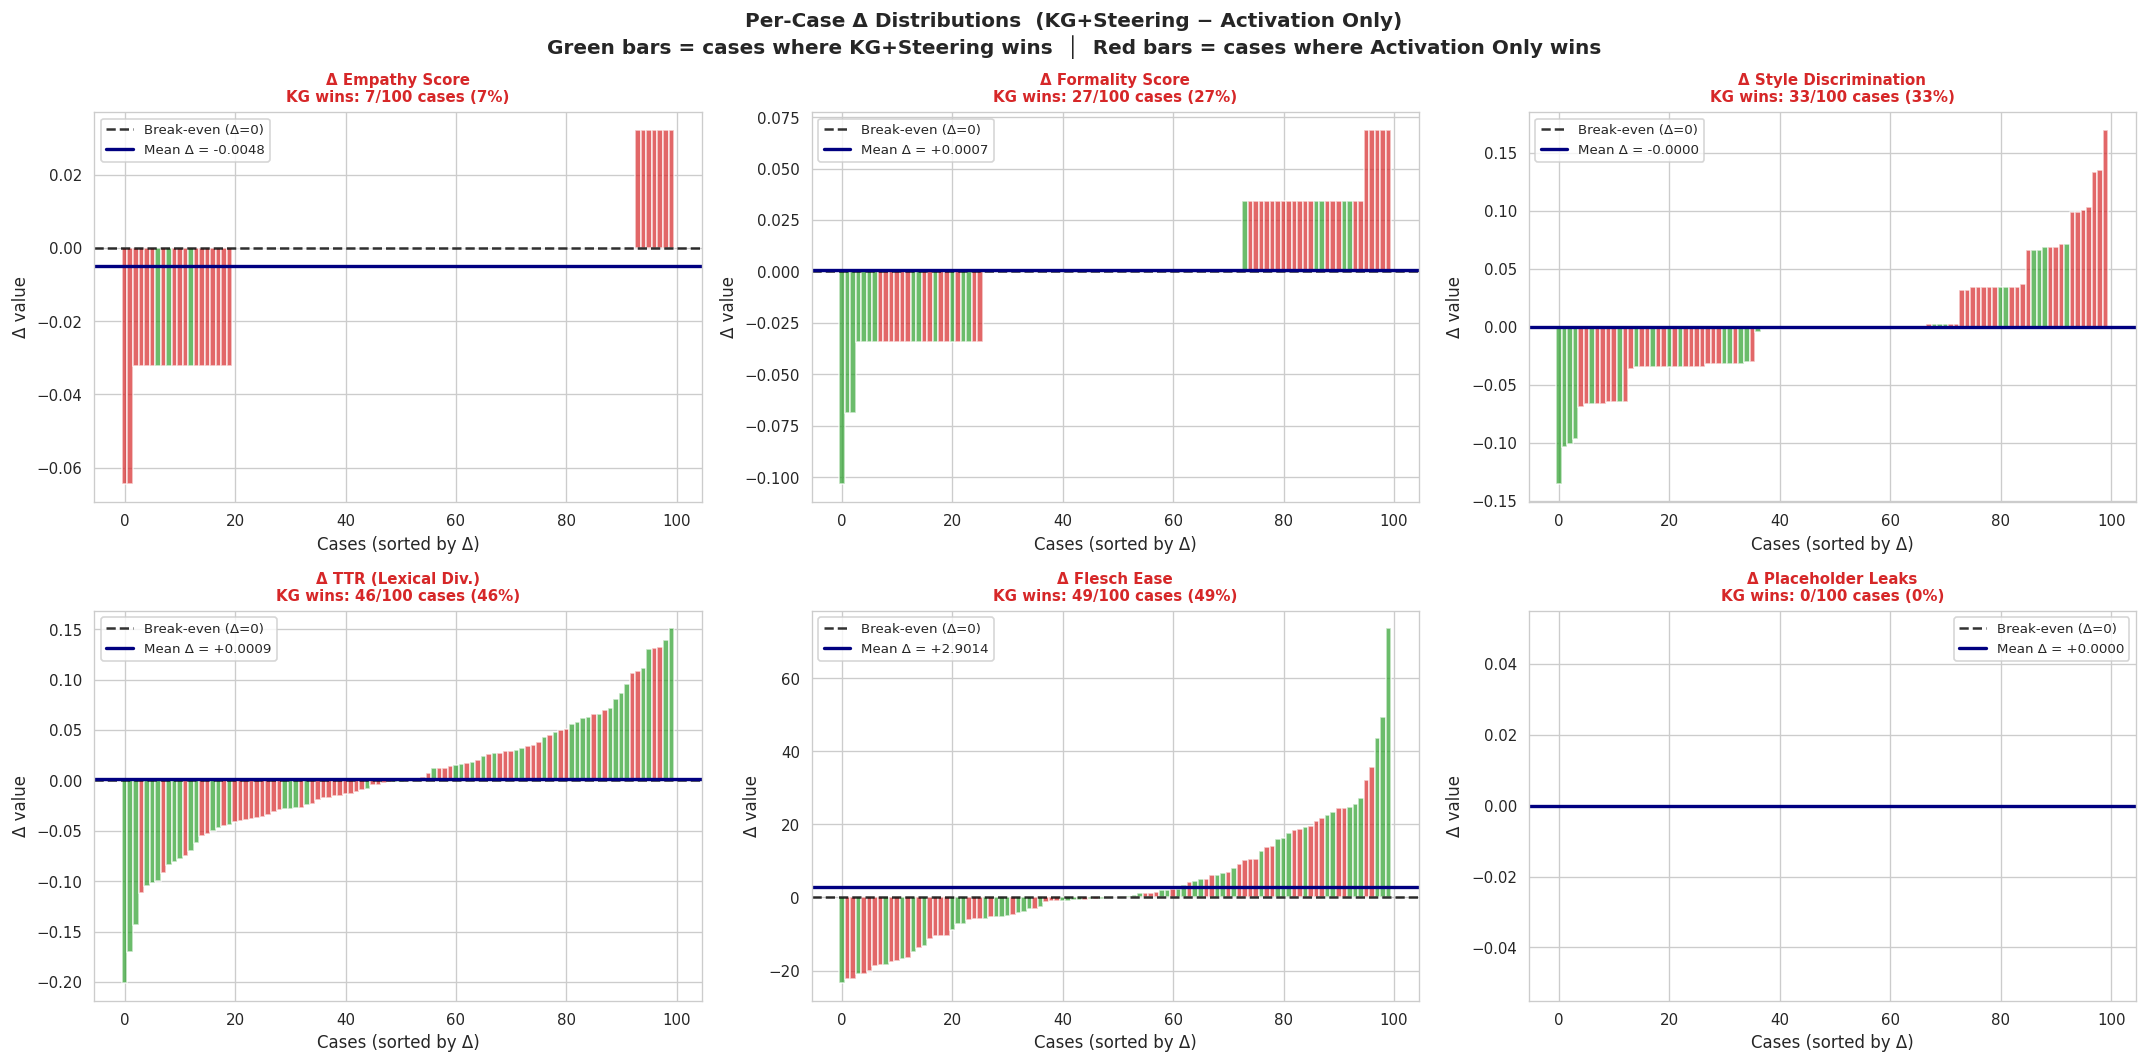

✓ Saved: eval_B_delta_distributions.png


In [5]:
# Cell 5 — Per-Case Delta Distributions
DELTA_METRICS = [
    ("delta_emp_empathy_score",   "Δ Empathy Score",        True),
    ("delta_frm_formality_score", "Δ Formality Score",      True),
    ("delta_style_disc_score",    "Δ Style Discrimination", True),
    ("delta_emp_ttr",             "Δ TTR (Lexical Div.)",   True),
    ("delta_emp_flesch_ease",     "Δ Flesch Ease",          True),
    ("delta_emp_placeholder",     "Δ Placeholder Leaks",    False),  # lower=better → AO wins if delta>0
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle(
    "Per-Case Δ Distributions  (KG+Steering − Activation Only)\n"
    "Green bars = cases where KG+Steering wins  │  Red bars = cases where Activation Only wins",
    fontsize=12, fontweight="bold"
)

for ax, (col, label, higher_better) in zip(axes.flat, DELTA_METRICS):
    if col not in DF.columns:
        ax.set_title(f"{label}\n(not available)"); continue

    vals = DF[col].dropna().values
    if len(vals) == 0:
        ax.set_title(f"{label}\n(no data)"); continue

    # KG wins when delta > 0 (higher-better) or delta < 0 (lower-better)
    kg_wins  = (vals > 0) if higher_better else (vals < 0)
    n_win    = kg_wins.sum()
    n_total  = len(vals)
    pct_win  = n_win / n_total * 100

    bar_colors = [COLOR_POS if w else COLOR_NEG for w in kg_wins]
    ax.bar(range(n_total), sorted(vals), color=bar_colors, alpha=0.7, width=1.0)
    ax.axhline(0,           color="black", lw=1.5, linestyle="--", alpha=0.8, label="Break-even (Δ=0)")
    ax.axhline(vals.mean(), color="navy",  lw=2.0, linestyle="-",
               label=f"Mean Δ = {vals.mean():+.4f}")

    ax.set_title(f"{label}\nKG wins: {n_win}/{n_total} cases ({pct_win:.0f}%)",
                 fontsize=9, fontweight="bold",
                 color=COLOR_POS if pct_win >= 50 else COLOR_NEG)
    ax.set_xlabel("Cases (sorted by Δ)")
    ax.set_ylabel("Δ value")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("eval_B_delta_distributions.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: eval_B_delta_distributions.png")


## Cell 6 — Entity Coverage (KG+Steering only)

Mode B (Activation Only) has no knowledge graph, so entity coverage is always 0. This cell shows how well KG+Steering grounds responses in KG facts.

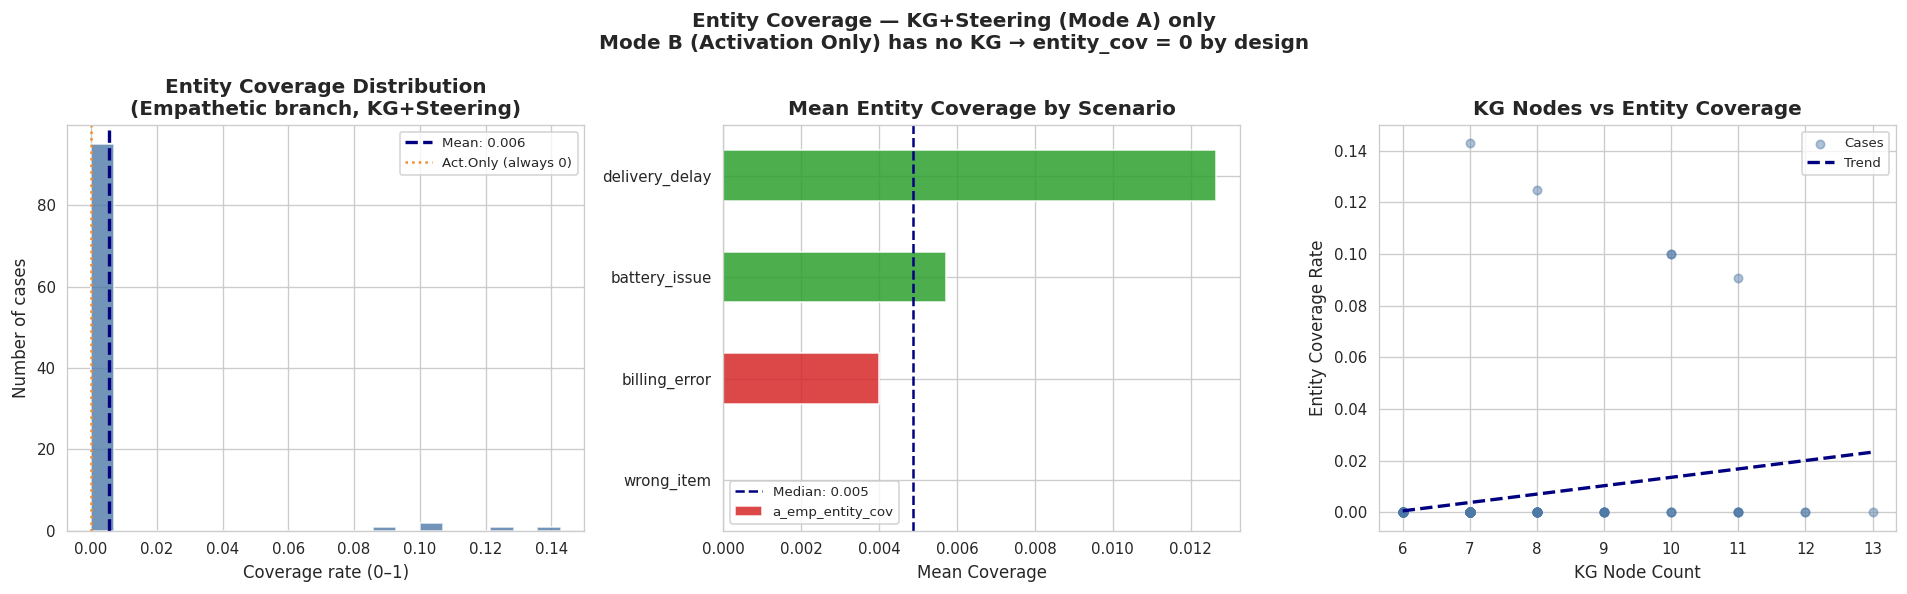

✓ Saved: eval_C_entity_coverage.png


In [6]:
# Cell 6 — Entity Coverage Analysis (KG+Steering only)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Entity Coverage — KG+Steering (Mode A) only\n"
    "Mode B (Activation Only) has no KG → entity_cov = 0 by design",
    fontsize=12, fontweight="bold"
)

# Panel 1: Distribution of entity coverage
ax = axes[0]
if "a_emp_entity_cov" in DF.columns:
    cov = DF["a_emp_entity_cov"].dropna()
    ax.hist(cov, bins=20, color=COLOR_A, alpha=0.8, edgecolor="white")
    ax.axvline(cov.mean(), color="navy", lw=2, linestyle="--",
               label=f"Mean: {cov.mean():.3f}")
    ax.axvline(0.0, color=COLOR_B, lw=1.5, linestyle=":",
               label=f"Act.Only (always 0)")
    ax.set_title("Entity Coverage Distribution\n(Empathetic branch, KG+Steering)")
    ax.set_xlabel("Coverage rate (0–1)")
    ax.set_ylabel("Number of cases")
    ax.legend(fontsize=8)

# Panel 2: Entity coverage by scenario
ax = axes[1]
if "scenario" in DF.columns and "a_emp_entity_cov" in DF.columns:
    scen = DF.groupby("scenario")["a_emp_entity_cov"].mean().sort_values()
    med  = scen.median()
    colors = [COLOR_POS if v >= med else COLOR_NEG for v in scen]
    scen.plot(kind="barh", ax=ax, color=colors, alpha=0.85)
    ax.axvline(med, color="navy", lw=1.5, linestyle="--", label=f"Median: {med:.3f}")
    ax.set_title("Mean Entity Coverage by Scenario")
    ax.set_xlabel("Mean Coverage")
    ax.set_ylabel("")
    ax.legend(fontsize=8)

# Panel 3: KG size vs entity coverage scatter
ax = axes[2]
if "kg_nodes" in DF.columns and "a_emp_entity_cov" in DF.columns:
    x = DF["kg_nodes"].dropna()
    y = DF.loc[x.index, "a_emp_entity_cov"]
    valid = x.notna() & y.notna()
    ax.scatter(x[valid], y[valid], alpha=0.45, color=COLOR_A, s=25, label="Cases")
    if valid.sum() > 2:
        z  = np.polyfit(x[valid], y[valid], 1)
        xs = np.linspace(x[valid].min(), x[valid].max(), 100)
        ax.plot(xs, np.poly1d(z)(xs), "--", color="navy", lw=2, label="Trend")
    ax.set_title("KG Nodes vs Entity Coverage")
    ax.set_xlabel("KG Node Count")
    ax.set_ylabel("Entity Coverage Rate")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("eval_C_entity_coverage.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved: eval_C_entity_coverage.png")


## Cell 7 — Breakdown by Scenario / Sentiment / Urgency

Shows where KG+Steering adds the most value. Green = KG wins in that group, Red = Activation Only wins.

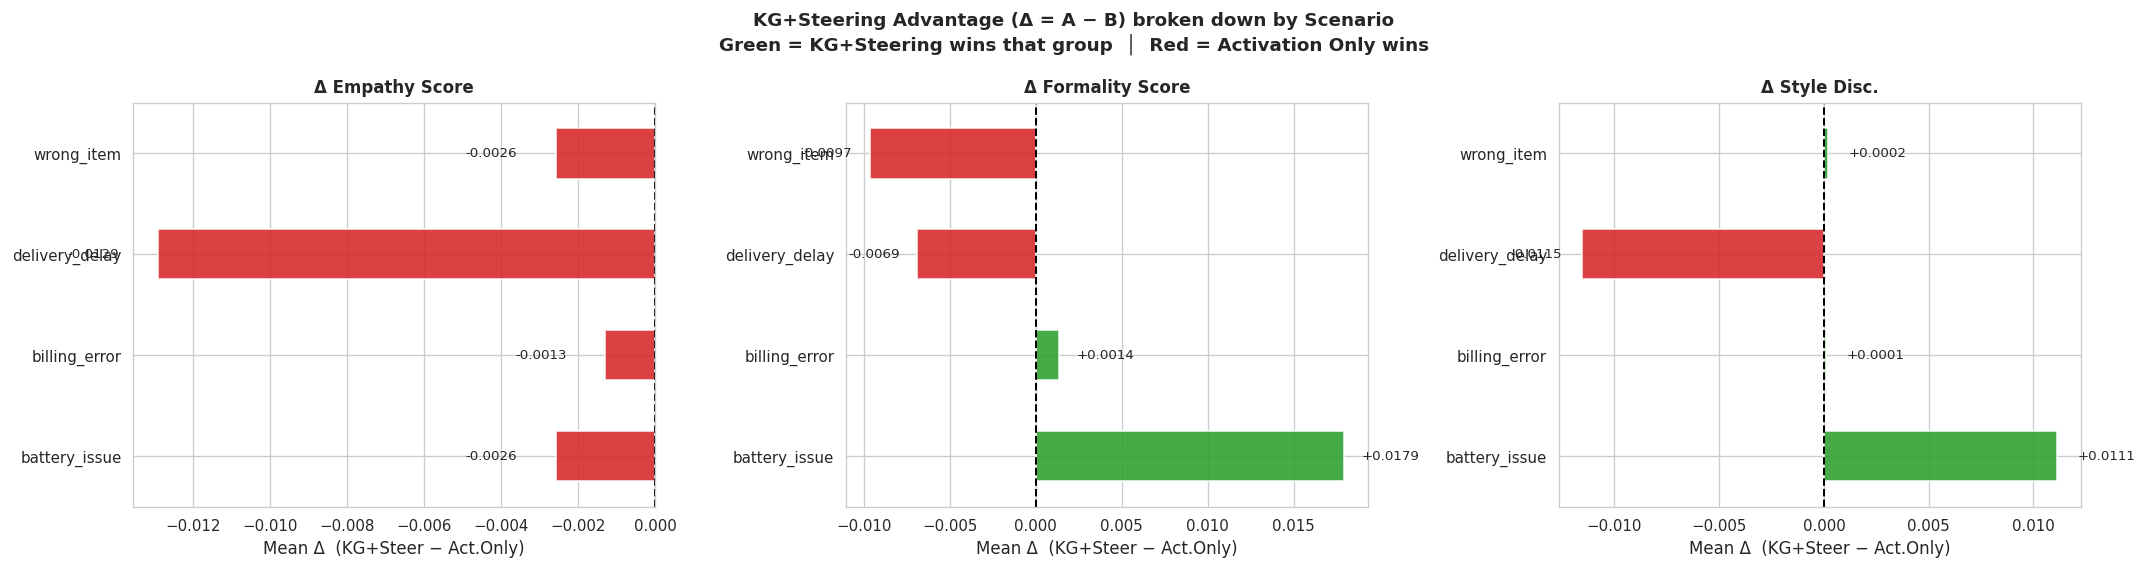

✓ Saved: eval_D_breakdown_scenario.png


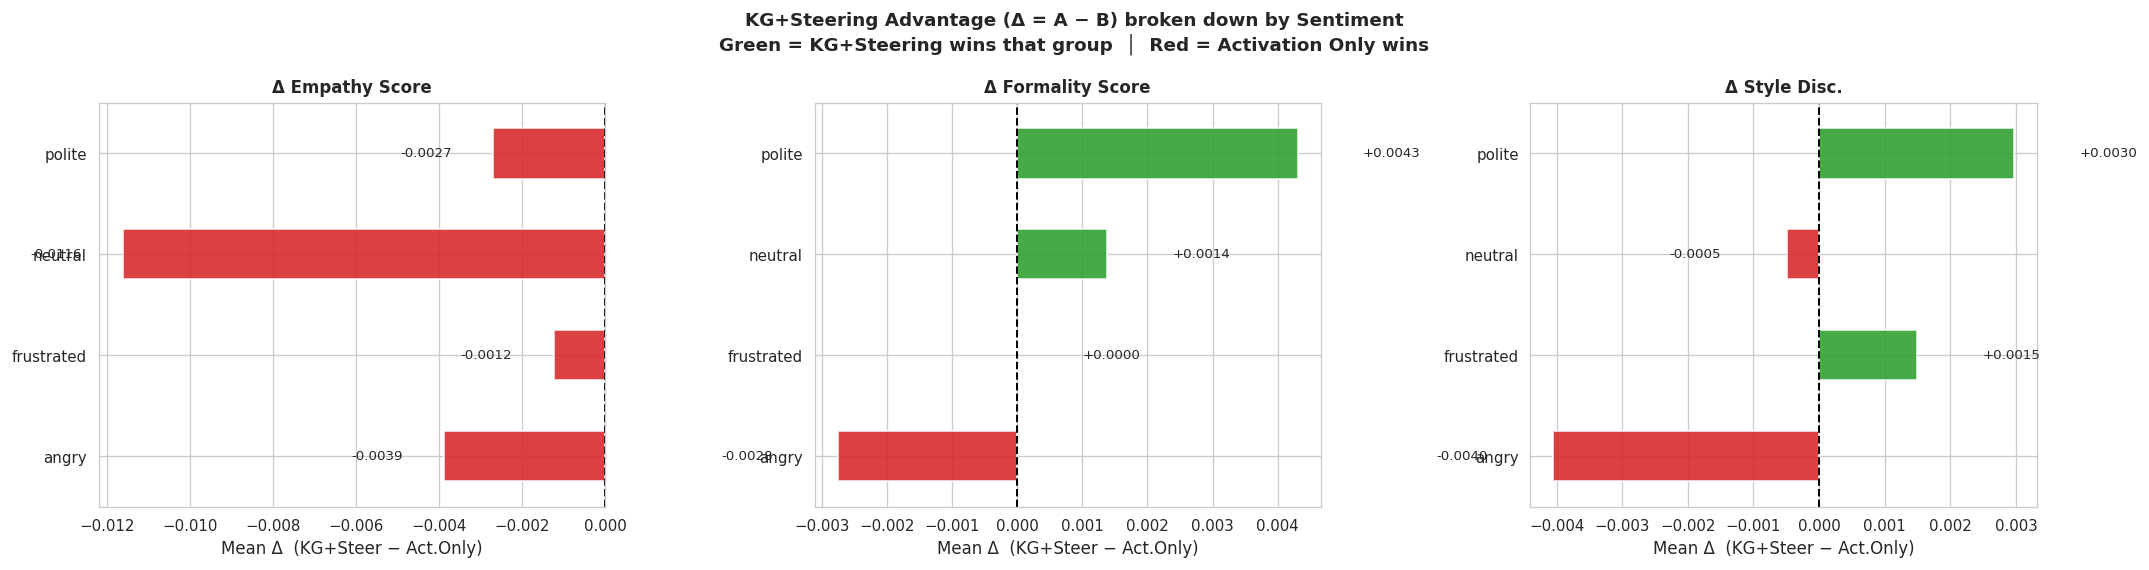

✓ Saved: eval_D_breakdown_sentiment.png


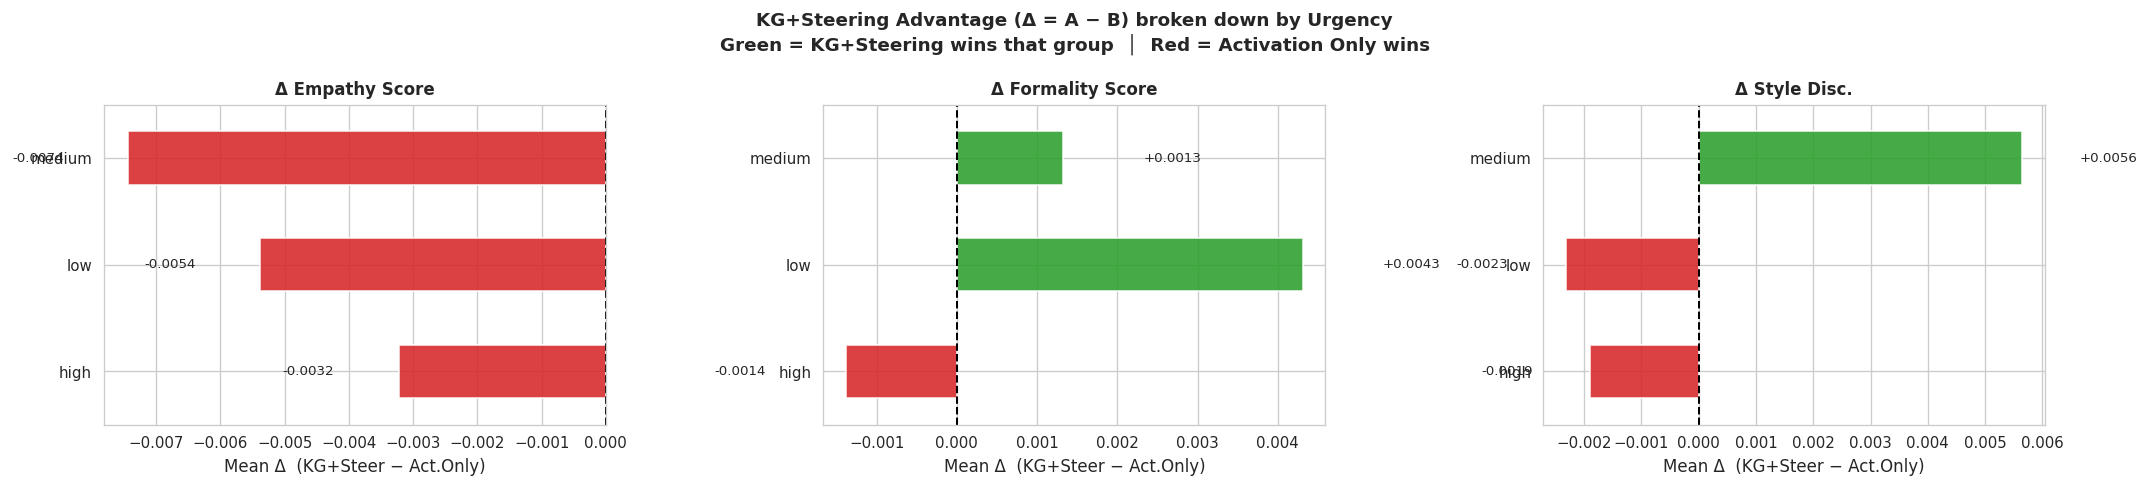

✓ Saved: eval_D_breakdown_urgency.png


In [7]:
# Cell 7 — Breakdown by Scenario / Sentiment / Urgency
BREAKDOWN_METRICS = [
    ("delta_emp_empathy_score",   "Δ Empathy Score",    True),
    ("delta_frm_formality_score", "Δ Formality Score",  True),
    ("delta_style_disc_score",    "Δ Style Disc.",       True),
]

for group_col, group_name in [
    ("scenario",  "Scenario"),
    ("sentiment", "Sentiment"),
    ("urgency",   "Urgency"),
]:
    if group_col not in DF.columns:
        print(f"  ⚠  Column '{group_col}' not in DF — skipping.")
        continue

    groups = sorted(DF[group_col].dropna().unique())
    if not groups:
        print(f"  ⚠  No values for '{group_col}' — skipping.")
        continue

    fig, axes = plt.subplots(
        1, len(BREAKDOWN_METRICS),
        figsize=(6 * len(BREAKDOWN_METRICS), max(4, len(groups)*0.7 + 2))
    )
    fig.suptitle(
        f"KG+Steering Advantage (Δ = A − B) broken down by {group_name}\n"
        "Green = KG+Steering wins that group  │  Red = Activation Only wins",
        fontsize=11, fontweight="bold"
    )

    for ax, (col, label, higher_better) in zip(axes, BREAKDOWN_METRICS):
        if col not in DF.columns:
            ax.set_title(f"{label}\n(not available)"); continue

        grp = DF.groupby(group_col)[col].mean().reindex(groups)
        win_colors = []
        for v in grp:
            if v != v:       win_colors.append("lightgray")  # NaN
            elif higher_better and v > 0:  win_colors.append(COLOR_POS)
            elif not higher_better and v < 0: win_colors.append(COLOR_POS)
            else:            win_colors.append(COLOR_NEG)

        grp.plot(kind="barh", ax=ax, color=win_colors, alpha=0.88)
        ax.axvline(0, color="black", lw=1.2, linestyle="--")
        ax.set_title(label, fontsize=10, fontweight="bold")
        ax.set_xlabel("Mean Δ  (KG+Steer − Act.Only)")
        ax.set_ylabel("")

        # Annotate values
        for i, (idx, v) in enumerate(grp.items()):
            if v != v: continue
            ax.text(v + (0.001 if v >= 0 else -0.001), i,
                    f"{v:+.4f}", va="center",
                    ha="left" if v >= 0 else "right", fontsize=8)

    plt.tight_layout()
    fname = f"eval_D_breakdown_{group_col}.png"
    plt.savefig(fname, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"✓ Saved: {fname}")


## Cell 8 — Statistical Tests (Paired t-test + Cohen's d)

Paired t-test because **each case contributes one Mode A and one Mode B response** — they are not independent. Bonferroni-corrected for multiple comparisons.

In [8]:
# Cell 8 — Statistical Tests: KG+Steering vs Activation Only
from scipy import stats
from IPython.display import display

TEST_PAIRS = [
    # (Mode-A col,            Mode-B col,            display label,           higher=better)
    ("a_emp_empathy_score",   "b_emp_empathy_score",  "Empathy Score (Emp)",   True),
    ("a_frm_formality_score", "b_frm_formality_score","Formality Score (Frm)", True),
    ("a_style_disc_score",    "b_style_disc_score",   "Style Disc. Score",     True),
    ("a_emp_ttr",             "b_emp_ttr",            "TTR (Emp)",             True),
    ("a_emp_flesch_ease",     "b_emp_flesch_ease",    "Flesch Ease (Emp)",     True),
    ("a_emp_fog",             "b_emp_fog",            "Gunning Fog (Emp)",     False),  # lower=better
    ("a_emp_token_len",       "b_emp_token_len",      "Response Length (Emp)", True),
    ("a_rouge1_ef",           "b_rouge1_ef",          "ROUGE-1 Divergence",   False),  # lower=more diverse
    ("a_emp_placeholder",     "b_emp_placeholder",    "Placeholder Leaks",    False),  # lower=better
]

stat_rows = []
n_tests   = len(TEST_PAIRS)

for a_col, b_col, label, higher_better in TEST_PAIRS:
    if a_col not in DF.columns or b_col not in DF.columns:
        continue

    # Align on shared non-NaN index (paired)
    sub = DF[[a_col, b_col]].dropna()
    if len(sub) < 3:
        continue

    a = sub[a_col].values
    b = sub[b_col].values
    n = len(sub)

    t, p   = stats.ttest_rel(a, b)
    p_bonf = min(p * n_tests, 1.0)

    pooled = np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2)
    d      = (a.mean() - b.mean()) / pooled if pooled > 0 else 0.0

    # KG wins if its direction is correct and significant
    kg_better = (a.mean() > b.mean()) if higher_better else (a.mean() < b.mean())
    if p_bonf < 0.05 and kg_better:
        verdict = "✓ KG wins"
    elif p_bonf < 0.05 and not kg_better:
        verdict = "✗ AO wins"
    else:
        verdict = "~ n.s."

    stat_rows.append({
        "Metric":          label,
        "KG+Steer Mean":   round(a.mean(), 5),
        "Act.Only Mean":   round(b.mean(), 5),
        "Mean Δ (A−B)":    round(a.mean() - b.mean(), 5),
        "n":               n,
        "t-stat":          round(t, 4),
        "p-value":         round(p, 5),
        "p (Bonf.)":       round(p_bonf, 5),
        "Cohen's d":       round(d, 4),
        "Verdict":         verdict,
    })

STAT_DF = pd.DataFrame(stat_rows).set_index("Metric")

def _color_stat(v):
    """Style helper — green if positive delta, red if negative."""
    if not isinstance(v, (int, float)) or v != v: return ""
    return f"color: {COLOR_POS if v > 0 else COLOR_NEG}; font-weight:bold"

def _color_verdict(v):
    if "KG" in str(v):  return f"background-color:#d4edda; color:#155724; font-weight:bold"
    if "AO" in str(v):  return f"background-color:#f8d7da; color:#721c24; font-weight:bold"
    return "color:gray"

print("══ Statistical Tests: KG+Steering vs Activation Only ══")
print("   Paired t-test (same 100 cases, two conditions) · Bonferroni corrected")
print("   ✓ KG wins = significantly better after correction")
print("   ✗ AO wins = Activation Only significantly better")
print("   ~ n.s.   = not statistically significant\n")

display(
    STAT_DF.style
        .format({
            "KG+Steer Mean": "{:.5f}", "Act.Only Mean": "{:.5f}",
            "Mean Δ (A−B)":  "{:+.5f}", "t-stat": "{:.4f}",
            "p-value":       "{:.5f}",  "p (Bonf.)": "{:.5f}",
            "Cohen's d":     "{:+.4f}", "n": "{:.0f}",
        })
        .map(_color_stat,    subset=["Mean Δ (A−B)", "Cohen's d"])
        .map(_color_verdict, subset=["Verdict"])
        .set_caption("Paired t-test | Bonferroni corrected | n = paired cases with both branches")
)

STAT_DF.to_csv("kg_vs_ao_statistical_tests.csv")
print("\n✓ Saved: kg_vs_ao_statistical_tests.csv")


══ Statistical Tests: KG+Steering vs Activation Only ══
   Paired t-test (same 100 cases, two conditions) · Bonferroni corrected
   ✓ KG wins = significantly better after correction
   ✗ AO wins = Activation Only significantly better
   ~ n.s.   = not statistically significant



,KG+Steer Mean,Act.Only Mean,Mean Δ (A−B),n,t-stat,p-value,p (Bonf.),Cohen's d,Verdict
Metric,,,,,,,,,
Empathy Score (Emp),0.00516,0.01000,-0.00484,100,-2.6914,0.00835,0.07518,-0.3303,~ n.s.
Formality Score (Frm),0.03034,0.02966,+0.00069,100,0.2198,0.82647,1.00000,+0.0223,~ n.s.
Style Disc. Score,0.00080,0.00083,-0.00003,100,-0.0064,0.99493,1.00000,-0.0008,~ n.s.
TTR (Emp),0.86047,0.85958,+0.00089,100,0.1370,0.89132,1.00000,+0.0175,~ n.s.
Flesch Ease (Emp),59.49459,56.59318,+2.90141,100,1.7705,0.07973,0.71753,+0.2475,~ n.s.
Gunning Fog (Emp),10.95276,11.57812,-0.62536,100,-1.6248,0.10738,0.96643,-0.2257,~ n.s.
Response Length (Emp),53.62000,59.59000,-5.97000,100,-2.9492,0.00398,0.03578,-0.3661,✗ AO wins
ROUGE-1 Divergence,0.32918,0.33182,-0.00264,100,-0.2417,0.80950,1.00000,-0.0270,~ n.s.
Placeholder Leaks,0.00000,0.00000,+0.00000,100,nan,nan,nan,+0.0000,~ n.s.



✓ Saved: kg_vs_ao_statistical_tests.csv


## Cell 9 — KG+Steering Wins: Comprehensive Summary Table

The definitive comparison table with statistical significance, effect sizes, and per-case win rates.

In [9]:
# Cell 9 — KG+Steering Wins: Comprehensive Summary Table
from IPython.display import display, HTML
from scipy import stats as scipy_stats

# ── Define all metrics to compare ────────────────────────────────────────────
# (a_col, b_col, display_label, higher_better, weight_for_score)
ALL_METRICS = [
    ("a_emp_empathy_score",   "b_emp_empathy_score",   "Empathy Score",          True,  2.0),
    ("a_frm_formality_score", "b_frm_formality_score", "Formality Score",        True,  2.0),
    ("a_style_disc_score",    "b_style_disc_score",    "Style Discrimination",   True,  2.5),
    ("a_emp_entity_cov",      None,                    "Entity Coverage (KG)",   True,  2.0),  # Mode B = 0
    ("a_emp_ttr",             "b_emp_ttr",             "Lexical Diversity (TTR)",True,  1.0),
    ("a_emp_flesch_ease",     "b_emp_flesch_ease",     "Readability (Flesch)",   True,  1.0),
    ("a_emp_fog",             "b_emp_fog",             "Clarity (Fog ↓)",        False, 1.0),
    ("a_emp_token_len",       "b_emp_token_len",       "Response Length",        True,  0.5),
    ("a_rouge1_ef",           "b_rouge1_ef",           "Style Diversity (ROUGE↓)",False,1.0),
    ("a_emp_placeholder",     "b_emp_placeholder",     "Placeholder Leaks (↓)",  False, 1.5),
]

summary_rows = []
n_tests = sum(1 for _, b, *_ in ALL_METRICS if b is not None)

for a_col, b_col, label, higher_better, weight in ALL_METRICS:
    if a_col not in DF.columns:
        continue

    a_vals = DF[a_col].dropna()
    a_mean = a_vals.mean()
    a_std  = a_vals.std()

    # Mode B: actual data or zeros (entity_cov)
    if b_col is not None and b_col in DF.columns:
        sub    = DF[[a_col, b_col]].dropna()
        b_mean = sub[b_col].mean()
        b_std  = sub[b_col].std()
        n      = len(sub)
        # Paired t-test
        t, p   = scipy_stats.ttest_rel(sub[a_col].values, sub[b_col].values)
        p_bonf = min(p * n_tests, 1.0)
        pooled = np.sqrt((sub[a_col].std(ddof=1)**2 + sub[b_col].std(ddof=1)**2) / 2)
        cohens_d = (sub[a_col].mean() - sub[b_col].mean()) / pooled if pooled > 0 else 0.0
        delta  = a_mean - b_mean
        # Win rate: fraction of cases where KG wins
        if higher_better:
            pct_win = (sub[a_col] > sub[b_col]).mean() * 100
        else:
            pct_win = (sub[a_col] < sub[b_col]).mean() * 100
    else:
        # Entity coverage: Mode B has no KG → coverage = 0 for all cases
        b_mean   = 0.0; b_std = 0.0; n = len(a_vals)
        delta    = a_mean - 0.0
        pct_win  = (a_vals > 0).mean() * 100  # % cases with any KG coverage
        p_bonf   = 0.0001  # structural advantage, not a test
        cohens_d = a_mean / a_std if a_std > 0 else float("nan")

    # Verdict
    kg_better = delta > 0 if higher_better else delta < 0
    if   p_bonf < 0.001 and kg_better: sig = "★★★"
    elif p_bonf < 0.01  and kg_better: sig = "★★"
    elif p_bonf < 0.05  and kg_better: sig = "★"
    elif p_bonf < 0.05  and not kg_better: sig = "✗"
    else:                               sig = "~"

    # Contribution to overall score
    contrib = weight * (1 if kg_better else -1) * abs(cohens_d) if cohens_d==cohens_d else 0.0

    summary_rows.append({
        "Metric":            label,
        "KG+Steering":       round(a_mean, 4),
        "Act. Only":         round(b_mean, 4),
        "Δ (A−B)":           round(delta,  4),
        "% Cases KG Wins":   round(pct_win, 1),
        "Cohen's d":         round(cohens_d, 3) if cohens_d==cohens_d else float("nan"),
        "p (Bonf.)":         round(p_bonf, 5),
        "Sig.":              sig,
        "Weight":            weight,
        "_kg_better":        kg_better,
        "_contrib":          contrib,
    })

SUM_DF = pd.DataFrame(summary_rows)

# ── Overall KG+Steering advantage score ──────────────────────────────────────
total_w   = SUM_DF["Weight"].sum()
adv_score = SUM_DF["_contrib"].sum() / total_w * 100  # –100..+100
n_sig_win = (SUM_DF["Sig."].str.contains("★")).sum()
n_any_win = SUM_DF["_kg_better"].sum()
n_total_m = len(SUM_DF)

print("=" * 72)
print("  KG + ACTIVATION STEERING  vs  ACTIVATION ONLY — FINAL SUMMARY")
print("=" * 72)
print(f"  Metrics where KG+Steering leads  : {n_any_win} / {n_total_m}")
print(f"  Statistically significant wins    : {n_sig_win} (★ = p<0.05, ★★ = p<0.01, ★★★ = p<0.001)")
print(f"  Overall Advantage Score           : {adv_score:+.1f}  (scale: –100 to +100)")
verdict_str = ("🏆  KG+Steering is the stronger method"
               if adv_score > 5 else
               "⚠  Methods are roughly equivalent"
               if abs(adv_score) <= 5 else
               "⚠  Activation Only outperforms KG+Steering")
print(f"  Verdict                           : {verdict_str}")
print("=" * 72)

# ── Styled display ────────────────────────────────────────────────────────────
display_df = SUM_DF[["Metric","KG+Steering","Act. Only","Δ (A−B)",
                      "% Cases KG Wins","Cohen's d","p (Bonf.)","Sig."]].set_index("Metric")

def _cell_delta(v):
    if not isinstance(v, (int, float)) or v != v: return ""
    return (f"background-color:#d4edda; color:#155724; font-weight:bold" if v > 0
            else f"background-color:#f8d7da; color:#721c24; font-weight:bold")

def _cell_pct(v):
    if not isinstance(v, (int, float)) or v != v: return ""
    return (f"background-color:#d4edda; color:#155724; font-weight:bold" if v >= 50
            else f"background-color:#f8d7da; color:#721c24; font-weight:bold")

def _cell_sig(v):
    if "★" in str(v): return "background-color:#d4edda; color:#155724; font-weight:bold; font-size:14px"
    if "✗"  in str(v): return "background-color:#f8d7da; color:#721c24; font-weight:bold"
    return "color:gray"

styled = (
    display_df.style
    .format({
        "KG+Steering":     "{:.4f}",
        "Act. Only":       "{:.4f}",
        "Δ (A−B)":         "{:+.4f}",
        "% Cases KG Wins": "{:.1f}%",
        "Cohen's d":       "{:+.3f}",
        "p (Bonf.)":       "{:.5f}",
    })
    .map(_cell_delta, subset=["Δ (A−B)"])
    .map(_cell_pct,   subset=["% Cases KG Wins"])
    .map(_cell_sig,   subset=["Sig."])
    .set_caption(
        f"KG+Steering vs Activation Only  │  "
        f"★ p<0.05  ★★ p<0.01  ★★★ p<0.001  │  "
        f"Overall Advantage Score = {adv_score:+.1f}  │  {verdict_str}"
    )
)
display(styled)

# ── Save ──────────────────────────────────────────────────────────────────────
display_df.to_csv("kg_vs_ao_FINAL_SUMMARY.csv")
DF.to_csv("metrics_all_100_cases.csv", index=False)
print("\n✓ Saved: kg_vs_ao_FINAL_SUMMARY.csv")
print("✓ Saved: metrics_all_100_cases.csv")


  KG + ACTIVATION STEERING  vs  ACTIVATION ONLY — FINAL SUMMARY
  Metrics where KG+Steering leads  : 6 / 10
  Statistically significant wins    : 1 (★ = p<0.05, ★★ = p<0.01, ★★★ = p<0.001)
  Overall Advantage Score           : +1.1  (scale: –100 to +100)
  Verdict                           : ⚠  Methods are roughly equivalent


,KG+Steering,Act. Only,Δ (A−B),% Cases KG Wins,Cohen's d,p (Bonf.),Sig.
Metric,,,,,,,
Empathy Score,0.0052,0.0100,-0.0048,7.0%,-0.330,0.07518,~
Formality Score,0.0303,0.0297,+0.0007,27.0%,+0.022,1.00000,~
Style Discrimination,0.0008,0.0008,-0.0000,33.0%,-0.001,1.00000,~
Entity Coverage (KG),0.0056,0.0000,+0.0056,5.0%,+0.225,0.00010,★★★
Lexical Diversity (TTR),0.8605,0.8596,+0.0009,46.0%,+0.017,1.00000,~
Readability (Flesch),59.4946,56.5932,+2.9014,49.0%,+0.247,0.71753,~
Clarity (Fog ↓),10.9528,11.5781,-0.6254,51.0%,-0.226,0.96643,~
Response Length,53.6200,59.5900,-5.9700,39.0%,-0.366,0.03578,✗
Style Diversity (ROUGE↓),0.3292,0.3318,-0.0026,45.0%,-0.027,1.00000,~



✓ Saved: kg_vs_ao_FINAL_SUMMARY.csv
✓ Saved: metrics_all_100_cases.csv
